# Analyse a FactBlock bundle, then hand the same data to an AI

Two years of Jim Cramer's market calls on CNBC (`samples/cramer`: 2,091 statements, 1,169 links he drew between them, 779 calls settled by the price move at their horizon), read three ways:

1. **How did his view on the market change?** A timeline of every call on SPY, up or down, and what became of it.
2. **What did one call rest on?** The statements linked to it, as he linked them.
3. **Where does he stand overall?** Calls per subject: came true, did not, no verdict yet, replaced.

Then one question goes to a model with the same data as its context, and every note it cites is traced back to the recording.

Every chart is computed in DuckDB over the Parquet profile with the macro pack (`duckdb/factblock.sql`), and every mark carries its FactBlock id and source URL. The analysis lives in [`views.py`](views.py) and returns plain dicts plus a Vega-Lite spec, so the same view can be rendered here, in a web page, or as an image in a chat answer. To use your own data, see the last section.

In [1]:
import os, re, sys
from IPython.display import display, Markdown
import factblock
sys.path.insert(0, ".")
import views

BRAIN = "../../samples/cramer"
AS_OF = "2026-09-10"                    # read everything known by this day
con, pq = views.connect(BRAIN)          # a Parquet copy of the bundle + the macro pack

def show(v):
    """Render a view: interactive Vega-Lite in Jupyter, a PNG where only images render (GitHub, chat)."""
    bundle = {"application/vnd.vegalite.v5+json": v["spec"], "text/plain": v["title"]}
    try:
        import vl_convert as vlc
        bundle["image/png"] = vlc.vegalite_to_png(v["spec"], scale=2)
    except ImportError:
        pass
    display(bundle, raw=True)

factblock.__version__

'1.0.0a3'

## 1. How did his view on the market change?

Each mark is one call on SPY, placed at the day it was said, up or down. Green triangles came true and red crosses did not, both by the price at the call's horizon. Grey means no verdict yet (or no horizon), and light squares were replaced by a later call. In Jupyter, hover for the statement and click to open the recording at the second it was said.

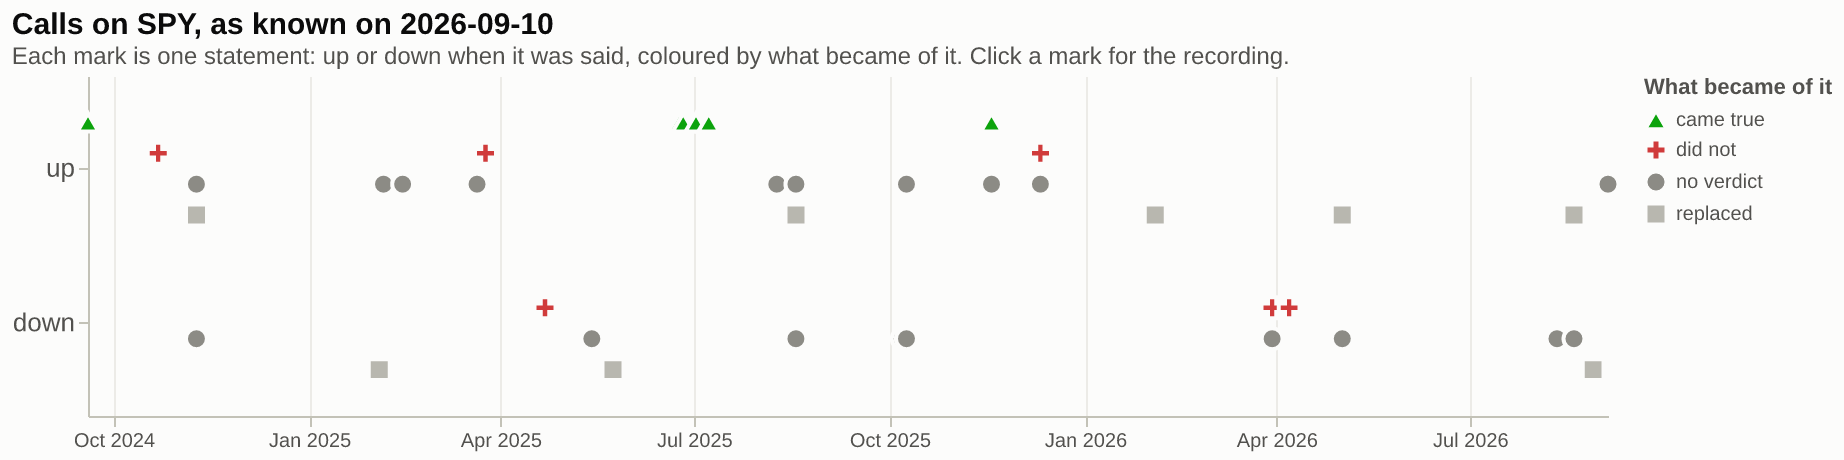

45 calls, 18 turns between up and down
2024-11-09  down  no verdict  [44119ff3255de35e]  The upcoming CPI report could put a damper on the market's buying momentum.
2025-02-05  up    no verdict  [c3e89c0a3c8d4079]  The President's current trade actions will ultimately be very positive for the s
2025-04-22  down  did not     [800b85cc67122bb6]  Bigger forces are at work that are going to crush the entire market, making this
2025-06-24  up    came true   [76e58107351aa955]  The stock market is positioned to go higher.
2025-08-18  down  no verdict  [5df734eafa4ba8a3]  A significant increase in interest rates causes a contraction in stock market P/
2025-08-18  up    no verdict  [212810fa6e3f239f]  For long-term investors, stocks are a better investment than bonds.


In [2]:
v = views.stance(con, pq, "SPY", AS_OF)
show(v)

# the turns: a call whose direction differs from the one before it
prev, turns = None, []
for r in v["rows"]:
    if prev and r["direction"] != prev:
        turns.append(r)
    prev = r["direction"]
print(f"{len(v['rows'])} calls, {len(turns)} turns between up and down")
for r in turns[:6]:
    print(f"{r['said']}  {r['direction']:<4}  {r['status']:<10}  [{r['id']}]  {r['statement'][:80]}")

## 2. What did one call rest on?

21 March 2025, a few weeks before the April tariff sell-off: "The stock market is positioned to move higher." On the left, what he gave as reasons; on the right, what he said next. Links are **recorded**, not verified: a blue line means he said one thing causes another, not that it does. The only checked part is the verdict colour on each statement.

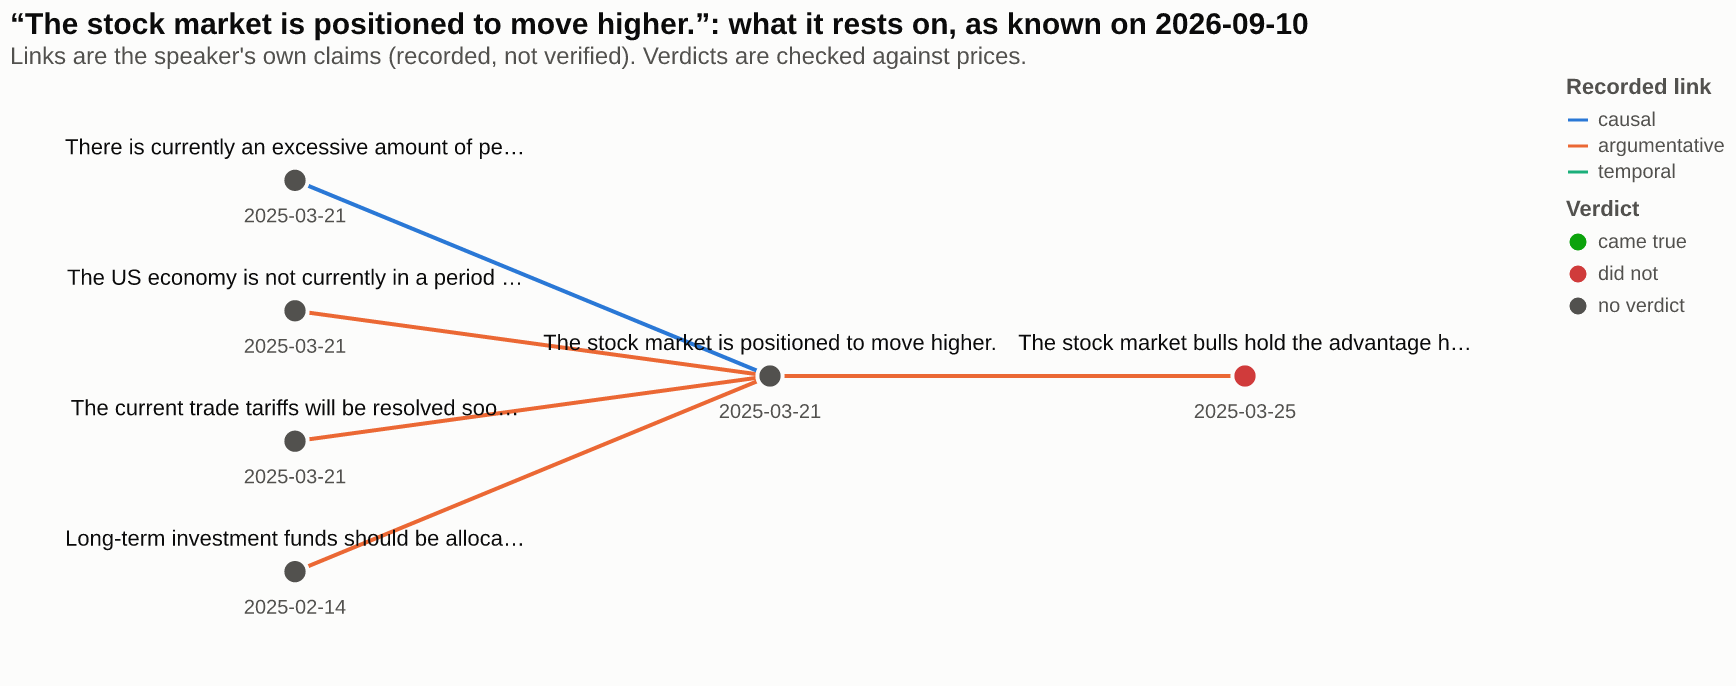

554789ad805f66cb -SUPPORTS-> fdc79a63b9b44a7f   (recorded by the speaker, not verified)
7c7f9d08e8c249e9 -SUPPORTS-> fdc79a63b9b44a7f   (recorded by the speaker, not verified)
909c01b4436033df -CAUSES-> fdc79a63b9b44a7f   (recorded by the speaker, not verified)
a90414c86ab67dfe -SUPPORTS-> fdc79a63b9b44a7f   (recorded by the speaker, not verified)
fdc79a63b9b44a7f -SUPPORTS-> ba4c1a04d78f5848   (recorded by the speaker, not verified)


In [3]:
v = views.evidence(con, pq, "fdc79a63b9b44a7f", AS_OF)
show(v)
for l in v["links"]:
    print(f"{l['source_id']} -{l['edge_type']}-> {l['target_id']}   ({l['basis']})")

## 3. Where does he stand overall?

The ten subjects he made the most calls on, split by what became of them. Hover a segment for the FactBlock ids behind it.

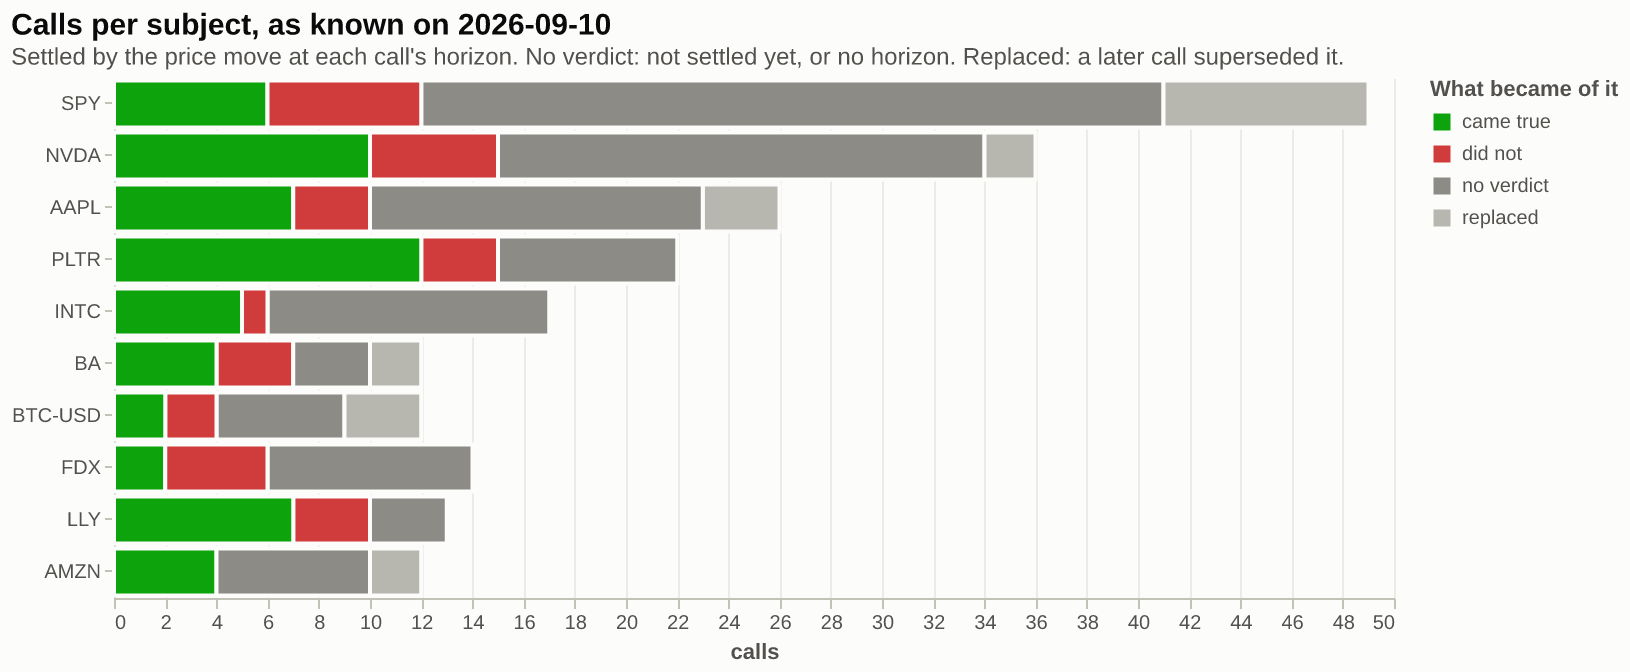

{'came true': 6, 'no verdict': 29, 'did not': 6, 'replaced': 8}

In [4]:
v = views.status(con, pq, AS_OF)
show(v)
spy = {r["status"]: r["n"] for r in v["rows"] if r["subject"] == "SPY"}
spy

### The same data in plain SQL

The views are ordinary SQL over the macro pack. Here is one query of your own: the hit rate of settled calls per subject, as known on two different days. Before a call's horizon passes its verdict does not exist yet, so the earlier read has fewer settled calls. This is the as-of rule doing its job, not missing data.

In [5]:
q = '''
SELECT json_extract_string(n.payload, '$.asset') AS subject,
       count(*) AS settled, round(avg((v.outcome = 'came_true')::INT), 2) AS hit_rate
  FROM read_parquet(? || '/nodes.parquet') n
  JOIN factblock_verdicts(?, factblock_day(?)) v ON v.target_id = n.id
 WHERE json_extract_string(n.payload, '$.asset') IN ('SPY', 'NVDA', 'AAPL', 'PLTR')
 GROUP BY 1 ORDER BY 1'''
for day in ("2025-06-01", AS_OF):
    print(day, con.execute(q, [pq, pq, day]).fetchall())

2025-06-01 [('AAPL', 5, 0.4), ('NVDA', 5, 0.2), ('PLTR', 4, 1.0), ('SPY', 3, 0.33)]


2026-09-10 [('AAPL', 10, 0.7), ('NVDA', 18, 0.61), ('PLTR', 15, 0.8), ('SPY', 12, 0.5)]


## 4. Ask a model, then check the source

The question is asked as of 24 March 2025. `factblock.context(..., ids=True)` gives the model only what was known that day, one line per statement with its id. The model is told to cite ids, and each cited id goes back to its recording.

Set `OPENAI_API_KEY` or `GEMINI_API_KEY` to get a real answer; without a key the cell prints the prompt the model would get. `views.pick()` chooses the chart that fits the question, which is what a chat answer would attach.

In [6]:
def ask_model(prompt):
    if os.environ.get("OPENAI_API_KEY"):
        from openai import OpenAI
        r = OpenAI().chat.completions.create(model=os.environ.get("OPENAI_MODEL", "gpt-4.1-mini"), messages=[{"role": "user", "content": prompt}])
        return r.choices[0].message.content
    if os.environ.get("GEMINI_API_KEY"):
        from google import genai
        return genai.Client().models.generate_content(model=os.environ.get("GEMINI_MODEL", "gemini-2.5-flash"), contents=prompt).text
    return None

question = "Is Cramer bullish on the stock market right now, and why?"
asked = "2025-03-24"
print("chart for this question:", views.pick(question))

ctx = factblock.context(BRAIN, "stock market higher", as_of=asked, ids=True, limit=8)
prompt = (f"Today is {asked}. Answer from these notes only, and cite the [id] of every note you use.\n\n"
          f"{ctx}\n\nQuestion: {question}")
answer = ask_model(prompt)
print(answer or "(no model key set; this is the prompt the model would get)\n\n" + prompt)

chart for this question: evidence
(no model key set; this is the prompt the model would get)

Today is 2025-03-24. Answer from these notes only, and cite the [id] of every note you use.

- [fdc79a63b9b44a7f] 2025-03-21 Jim Cramer: The stock market is positioned to move higher. (source: Unrelenting market negativity bringing about 'real but ignored value', says Jim Cramer)
- [d58f18a907b63a18] 2025-03-12 Jim Cramer: The stock market has an underlying desire to go higher. (source: Pres. Trump says he's not focused on the stock market, says Jim Cramer)
- [51d673dee38eb6a4] 2024-12-17 Jim Cramer: Retail investor participation in the stock market is at an all-time high. (source: Tesla's move since the election is one for the ages, says Jim Cramer)
- [487ae337ab9ba268] 2024-10-31 Jim Cramer: The current market dips are a buying opportunity in high-quality stocks that investors should act on starting tomorrow. (source: It's insane how frightened shareholders can get, says Jim Cramer)
  ended 

In [7]:
# every id the answer cites (or, without a model, every id in the context), back to the recording
b = factblock.Bundle(BRAIN)
by_id = {n["id"]: n for n in b.nodes}
for i in dict.fromkeys(re.findall(r"\[([0-9a-f]{16})\]", answer or ctx)):
    p = by_id[i].get("payload") or {}
    print(f"[{i}] {by_id[i]['statement']}")
    print(f"    quote:  \"{p.get('quote', '')[:110]}\"")
    print(f"    source: {p['source']['url']}\n")

[fdc79a63b9b44a7f] The stock market is positioned to move higher.
    quote:  "You can see that stocks want to go higher."
    source: https://www.youtube.com/watch?v=10ZTB57CcDA&t=70s

[d58f18a907b63a18] The stock market has an underlying desire to go higher.
    quote:  "But you can see just for a second when the Canadians got constructive that this market truly does want to go h"
    source: https://www.youtube.com/watch?v=VJUaA9_tBys&t=148s

[51d673dee38eb6a4] Retail investor participation in the stock market is at an all-time high.
    quote:  "FIRST THE PUBLIC IS BACK FROM THE STOCK MARKET, BIGGER THAN EVER."
    source: https://www.youtube.com/watch?v=w9h0MsnpmBk&t=84s

[487ae337ab9ba268] The current market dips are a buying opportunity in high-quality stocks that investors should act on starting tomorrow.
    quote:  "let the sellers have their way today but you can start buying tomorrow It's kind of my mantra"
    source: https://www.youtube.com/watch?v=du6nWXgDbFk&t=102s

[6f

A day later he added "The stock market bulls hold the advantage heading into April and beyond." Read it on 26 March and it is an open call; read it on 10 April and it has ended, settled as **did not** on 3 April by the price at its horizon. Nothing was edited in between: a resolution row became visible. A model asked on each day gets exactly what was known that day.

In [8]:
print(factblock.context(BRAIN, "bulls advantage April", as_of="2025-03-26", ids=True, limit=1))
print()
print(factblock.context(BRAIN, "bulls advantage April", as_of="2025-04-10", ids=True, limit=1))

- [ba4c1a04d78f5848] 2025-03-25 Jim Cramer: The stock market bulls hold the advantage heading into April and beyond. (due 2025-04-02; source: Cramer on markets: The bulls and the president hold the cards)
(as of 2025-03-26)



- [ba4c1a04d78f5848] 2025-03-25 Jim Cramer: The stock market bulls hold the advantage heading into April and beyond. (source: Cramer on markets: The bulls and the president hold the cards)
  ended 2025-04-02
  verdict: did_not (decided 2025-04-03 by process:factagora-influencer-backtest/0.1)
(as of 2025-04-10)


## Use your own data

The views need predictions with a subject and a direction; links and verdicts are optional. Start from [`template.csv`](template.csv), one row per call or verdict:

| column | meaning |
|---|---|
| `id` | your id for the call |
| `kind` | `prediction` |
| `said_at` | when it was said |
| `due` | the horizon (optional) |
| `text` | the statement |
| `asset` | the subject the views group by |
| `direction` | `up` or `down` |
| `speaker`, `source` | who said it, and where (a URL makes the marks clickable) |
| `replaces` | the id of an earlier call this one supersedes (optional) |
| `target`, `outcome`, `decided_at` | a verdict row: `came_true` or `did_not` for the call `target` |

```bash
factblock import my-calls.csv --backfill -o my-brain/
```

Then set `BRAIN = "my-brain"` at the top and run the notebook again. Causal and argumentative links (view 2) come from `factblock extract` on the transcripts, or from your own `edges.jsonl` rows.